# Experiment 6.3 — Trimmer Clustering Stability

`ClusteringTrimmer` clusters points in descriptor space with DBSCAN and discards the large
clusters (6.1–6.2). Source and target are clustered separately, so trimming only removes the
same regions on both sides if the clustering survives noise and dropout.

For each cloud style, cluster the descriptors of a clean cloud, perturb the cloud with dropout
and jitter, re-cluster, and compare the two labelings on the surviving points via the Adjusted
Rand Index (ARI): 1 means the perturbation did not change which points are grouped together,
0 means agreement no better than chance. Jitter is in units of point spacing.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.metrics import adjusted_rand_score
from tabulate import tabulate

from point_cloud import PointCloud
from synthetic import SyntheticExperiment, CloudStyle
from feature_extractor import FeatureExtractor, GeometricFeatureExtractor, RobustGeometricFeatureExtractor, zscored_features
from visualization import ErrorMetricsVisualizer

STYLES: list[CloudStyle] = ['random', 'clustered', 'lattice', '2d-lattice', 'muscle-fiber']
EXTRACTOR_LABELS = ['Geometric', 'Robust']
EXTRACTOR_CLASSES = [GeometricFeatureExtractor, RobustGeometricFeatureExtractor]
EXTRACTOR_COLORS = {'Geometric': 'tab:orange', 'Robust': 'tab:green'}
SEED = 0

N_POINTS_CLUSTER = 3000
# (label, dropout_prob, jitter_std) — severity increases jointly in both axes.
SEVERITY_LEVELS = [
    ('none', 0.0, 0.0),
    ('mild', 0.05, 0.3),
    ('moderate', 0.15, 0.8),
    ('severe', 0.30, 1.5),
]
N_REPEATS = 5

K_SWEEP = [5, 8, 12, 20, 35, 50, 80, 160]
N_REPEATS_K_SWEEP = 3

In [2]:
def cluster_labels(cloud: PointCloud, extractor: FeatureExtractor) -> np.ndarray:
    """DBSCAN cluster labels for a cloud's z-scored feature vectors.

    Uses the same eps / min_samples rule as the trimmer configurations in 6.2, 8 and 9.

    Args:
        cloud: Point cloud with N points.
        extractor: FeatureExtractor producing per-point features.

    Returns:
        Per-point cluster label array of shape (N,); -1 marks noise.
    """
    features = zscored_features(extractor, [cloud])[0]
    d = features.shape[1]
    eps = (2 * d) ** 0.5 * 0.2
    db = DBSCAN(eps=eps, min_samples=int(np.log(len(cloud))))
    db.fit(features)
    return db.labels_


def perturb(
    cloud: PointCloud, dropout_prob: float, jitter_std: float, rng: np.random.Generator
) -> tuple[PointCloud, np.ndarray]:
    """Apply dropout (point removal) and Gaussian jitter to a cloud.

    Args:
        cloud: Point cloud to perturb.
        dropout_prob: Per-point probability of being dropped.
        jitter_std: Std of additive per-point Gaussian noise.
        rng: Random generator for reproducibility.

    Returns:
        Tuple of (perturbed cloud, boolean mask of points that survived dropout).
    """
    mask = rng.uniform(size=len(cloud)) >= dropout_prob
    points = cloud.points[mask] + rng.normal(0, jitter_std, size=(int(mask.sum()), 3))
    return PointCloud(points), mask


def stability_ari(
    clean_labels: np.ndarray,
    cloud: PointCloud,
    extractor: FeatureExtractor,
    dropout_prob: float,
    jitter_std: float,
    rng: np.random.Generator,
) -> float:
    """Adjusted Rand Index between clean and perturbed cluster labels.

    Args:
        clean_labels: Cluster labels of the unperturbed cloud.
        cloud: The same (unperturbed) point cloud clean_labels was computed from.
        extractor: FeatureExtractor used for clustering.
        dropout_prob: Per-point dropout probability applied before re-clustering.
        jitter_std: Std of Gaussian jitter applied before re-clustering.
        rng: Random generator for reproducibility.

    Returns:
        ARI between clean labels (restricted to surviving points) and perturbed
        labels. 1.0 when dropout_prob == jitter_std == 0, by construction.
    """
    if dropout_prob == 0.0 and jitter_std == 0.0:
        return 1.0
    perturbed_cloud, mask = perturb(cloud, dropout_prob, jitter_std, rng)
    perturbed_labels = cluster_labels(perturbed_cloud, extractor)
    return float(adjusted_rand_score(clean_labels[mask], perturbed_labels))

## 1. Choosing `k`

Sweep the neighbourhood size per (style, extractor) and pick the value that best preserves the
clustering at *mild* perturbation — a `k` already unstable there is a poor choice regardless of
how it behaves further out.

In [3]:
clouds_by_style = {style: SyntheticExperiment.generate(n=N_POINTS_CLUSTER, style=style, seed=SEED).S for style in STYLES}
mild_dropout, mild_jitter = next((dp, js) for label, dp, js in SEVERITY_LEVELS if label == 'mild')

rng_k = np.random.default_rng(SEED)
# (style, extractor) -> (len(K_SWEEP), N_REPEATS_K_SWEEP) ARI array, as expected by
# ErrorMetricsVisualizer.plot_parameter_sweep (mean/std computed over axis=1).
k_sweep_data: dict[tuple[str, str], np.ndarray] = {}

for style in STYLES:
    cloud = clouds_by_style[style]
    for ext_name, ext_cls in zip(EXTRACTOR_LABELS, EXTRACTOR_CLASSES):
        arr = np.empty((len(K_SWEEP), N_REPEATS_K_SWEEP))
        for i, k in enumerate(K_SWEEP):
            extractor = ext_cls(k=k)
            clean_labels = cluster_labels(cloud, extractor)
            for r in range(N_REPEATS_K_SWEEP):
                arr[i, r] = stability_ari(clean_labels, cloud, extractor, mild_dropout, mild_jitter, rng_k)
        k_sweep_data[(style, ext_name)] = arr

print(f'{len(k_sweep_data)} (style, extractor) sweeps over {len(K_SWEEP)} k values evaluated')

10 (style, extractor) sweeps over 8 k values evaluated


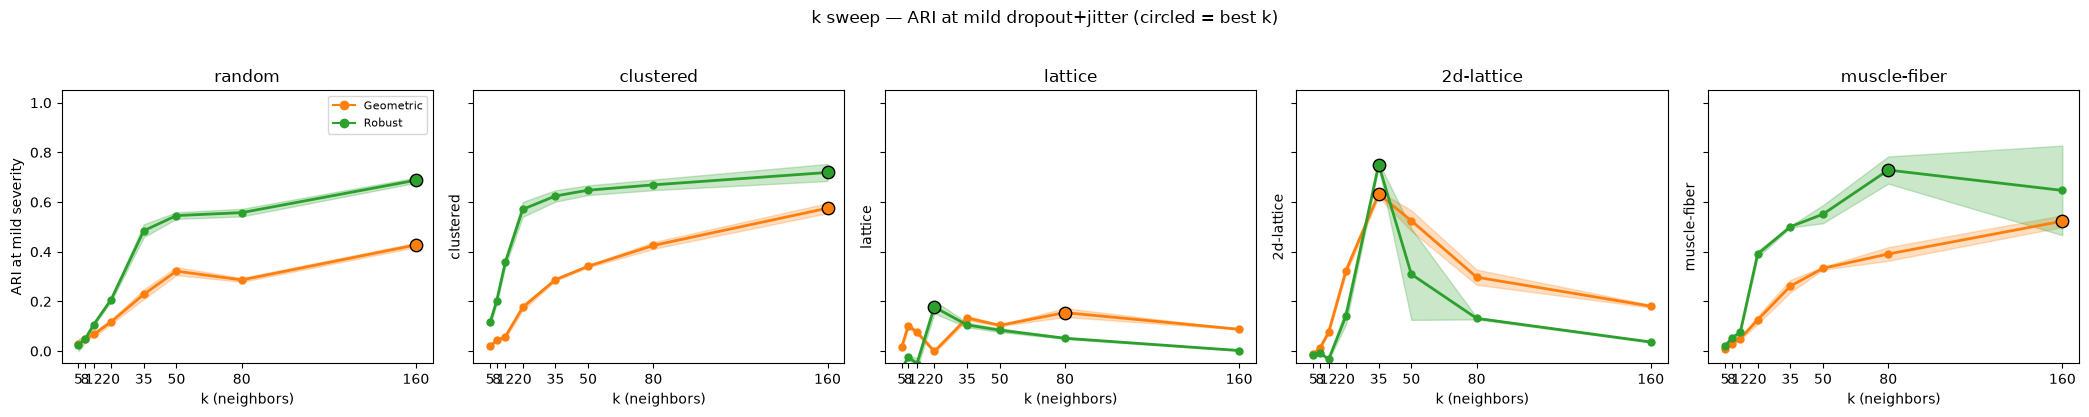

| style        | extractor   |   best k |
|--------------|-------------|----------|
| random       | Geometric   |      160 |
| random       | Robust      |      160 |
| clustered    | Geometric   |      160 |
| clustered    | Robust      |      160 |
| lattice      | Geometric   |       80 |
| lattice      | Robust      |       20 |
| 2d-lattice   | Geometric   |       35 |
| 2d-lattice   | Robust      |       35 |
| muscle-fiber | Geometric   |      160 |
| muscle-fiber | Robust      |       80 |


In [4]:
BEST_K: dict[tuple[str, str], int] = {
    key: K_SWEEP[int(arr.mean(axis=1).argmax())] for key, arr in k_sweep_data.items()
}

fig, axes = plt.subplots(1, len(STYLES), figsize=(4.2 * len(STYLES), 4), sharey=True)
for ext_name in EXTRACTOR_LABELS:
    data_per_style = [k_sweep_data[(style, ext_name)] for style in STYLES]
    ErrorMetricsVisualizer.plot_parameter_sweep(
        axes, K_SWEEP, data_per_style, y_labels=STYLES, x_label='k (neighbors)',
        colors=[EXTRACTOR_COLORS[ext_name]] * len(STYLES),
    )
for ax, style in zip(axes, STYLES):
    ax.set_ylim(-0.05, 1.05)
    for ext_name in EXTRACTOR_LABELS:
        best_k = BEST_K[(style, ext_name)]
        best_ari = k_sweep_data[(style, ext_name)].mean(axis=1)[K_SWEEP.index(best_k)]
        ax.scatter([best_k], [best_ari], color=EXTRACTOR_COLORS[ext_name], edgecolors='black', zorder=5, s=80)

axes[0].set_ylabel('ARI at mild severity')
axes[0].legend(
    handles=[plt.Line2D([0], [0], color=EXTRACTOR_COLORS[n], marker='o', label=n) for n in EXTRACTOR_LABELS],
    fontsize=8,
)
fig.suptitle('k sweep \u2014 ARI at mild dropout+jitter (circled = best k)', y=1.03)
plt.tight_layout()
plt.savefig('../results/6_3_trimmer_clustering_k_sweep.png', dpi=300, bbox_inches='tight')
plt.show()

print(tabulate(
    [[style, ext_name, BEST_K[(style, ext_name)]] for style in STYLES for ext_name in EXTRACTOR_LABELS],
    headers=['style', 'extractor', 'best k'], tablefmt='github',
))

## 2. Stability across severities

Each (style, extractor) at its best `k`.

In [5]:
rng = np.random.default_rng(SEED)
severities = [s for s, _, _ in SEVERITY_LEVELS]
# (style, extractor) -> (len(severities), N_REPEATS) ARI array.
severity_data: dict[tuple[str, str], np.ndarray] = {}

for style in STYLES:
    cloud = clouds_by_style[style]
    for ext_name, ext_cls in zip(EXTRACTOR_LABELS, EXTRACTOR_CLASSES):
        extractor = ext_cls(k=BEST_K[(style, ext_name)])
        clean_labels = cluster_labels(cloud, extractor)
        arr = np.empty((len(SEVERITY_LEVELS), N_REPEATS))
        for i, (_, dropout_prob, jitter_std) in enumerate(SEVERITY_LEVELS):
            for r in range(N_REPEATS):
                arr[i, r] = stability_ari(clean_labels, cloud, extractor, dropout_prob, jitter_std, rng)
        severity_data[(style, ext_name)] = arr

print(f'{sum(a.size for a in severity_data.values())} clustering-stability trials')

200 clustering-stability trials


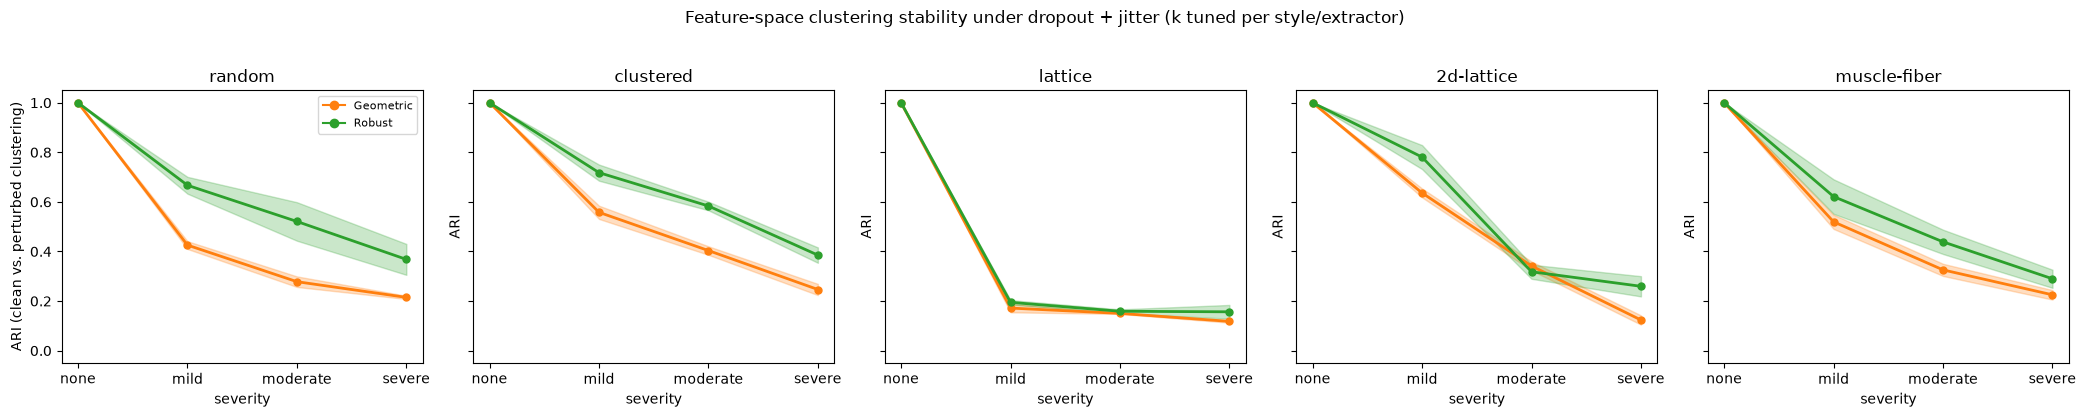

In [6]:
fig, axes = plt.subplots(1, len(STYLES), figsize=(4.2 * len(STYLES), 4), sharey=True)
for ext_name in EXTRACTOR_LABELS:
    data_per_style = [severity_data[(style, ext_name)] for style in STYLES]
    ErrorMetricsVisualizer.plot_parameter_sweep(
        axes=axes, x=severities, data_per_metric=data_per_style, y_labels=["ARI"] * len(STYLES), titles=STYLES, x_label='severity',
        colors=[EXTRACTOR_COLORS[ext_name]] * len(STYLES),
    )
for ax in axes:
    ax.set_ylim(-0.05, 1.05)

axes[0].set_ylabel('ARI (clean vs. perturbed clustering)')
axes[0].legend(
    handles=[plt.Line2D([0], [0], color=EXTRACTOR_COLORS[n], marker='o', label=n) for n in EXTRACTOR_LABELS],
    fontsize=8,
)
fig.suptitle('Feature-space clustering stability under dropout + jitter (k tuned per style/extractor)', y=1.03)
plt.tight_layout()
plt.savefig('../results/6_3_trimmer_clustering_stability.png', dpi=300, bbox_inches='tight')
plt.show()

### Observations

- **`Robust` clusters more stably than `Geometric` on the irregular styles** (`random`,
  `clustered`, `muscle-fiber`) at every severity. This differs from ICP, where the two tie at a
  large enough `k` (4.4): the extractor choice matters more for the trimmer than for matching.
- **Larger `k` helps on irregular styles**, and for `random` and `clustered` the best `k` is
  still the largest one tested, so the optimum may lie beyond it.
- **Lattices cluster unstably at any `k`.** On a regular grid most points have near-identical
  descriptors, so which cluster a point falls into is close to arbitrary and changes with the
  slightest perturbation.
- **Even at the best `k`, a mild perturbation changes the clustering substantially.** Source
  and target are clustered separately, so the trimmer removes partly different regions on the
  two sides — a limit worth keeping in mind when reading 6.2.